In [19]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.Hamiltonian import Hamiltonian
from scripts.Lattice import Lattice
from scripts.partial_sc import partial_sc


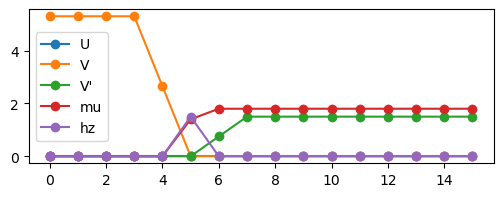

In [20]:
widthD = 5
widthF = 1
widthP = 10

X, Y = widthD+widthF+widthP, 100
lattice = Lattice(X, Y)

t = 1
T = 0.4

muD = 0.0 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthD] = muD
mu[widthD:widthD + widthF] = muF
mu[widthD + widthF:] = muP

h0 = 1.5 * t
h = np.zeros_like(mu)
h[widthD:widthD + widthF] = h0

U0 = 0.0 * t
U = U0 * np.ones(lattice.X)
U[widthD:] = 0
U[widthD-1] = U0/2

V0 = 5.3 * t
V = V0 * np.ones(lattice.X)
V[widthD:] = 0
V[widthD-1] = V0/2

V_prime0 = 1.5 * t
V_prime = V_prime0 * np.ones(lattice.X)
V_prime[:widthF+widthD] = 0
V_prime[widthF+widthD] = V_prime0/2

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(h, '-o', label='hz')

plt.legend()

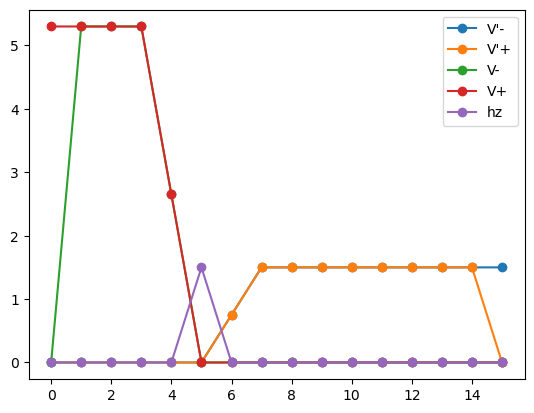

In [21]:
V_plus = np.r_[V[:-1], [0]]
V_minus = np.r_[[0], V[1:]]
Vprime_plus = np.r_[V_prime[:-1], [0]]
Vprime_minus = np.r_[[0], V_prime[1:]]

plt.plot(Vprime_minus, "-o", label="V'-")
plt.plot(Vprime_plus, "-o", label="V'+")
plt.plot(V_minus, "-o", label="V-")
plt.plot(V_plus, "-o", label="V+")
plt.plot(h, '-o', label='hz')
plt.legend()

In [22]:
from scripts.utils import is_hermitian


H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, g_s=V,
                F_init=[0.9, 0.9, -0.9, -0.9],
                Fuu_init=[0.1, -0.1, 0.1j, -0.1j],
                Fdd_init=[0.1, -0.1, 0.1j, -0.1j],
                hx=h)

print(is_hermitian(H.build_H_k(np.pi/4)))
print(is_hermitian(H.build_H_k0()))
print(is_hermitian(H.build_H_kindep()))


True
True
True


In [23]:
fixed_sites = (V != 0)
fixed_syms = ["F0", "F_xplus", "F_xmin", "F_yplus", "F_ymin"]
F_swave, F_dwave, F_px, F_py = partial_sc(H, temperature=T,
                                          fixed_sites=fixed_sites,
                                          fixed_syms=fixed_syms,
                                          atol=1e-3, rtol=1e-1, maxiter=500, 
                                          verbose=True)
F, Fuu, Fdd = H.get_correlations()

F0:
Absolute error: 0.005260683588572099
Relative error: 5260683588.5721
Average old: 0j
Average: (-0.00015823585701123287+0j)
F_xplus:
Absolute error: 0.0026072961330949338
Relative error: 2607296133.094934
Average old: (0.3+0j)
Average: (0.3001493191480246+0j)
F_xmin:
Absolute error: 0.005270367984240278
Relative error: 5270367984.240277
Average old: (0.3+0j)
Average: (0.30040163826177785+0j)
F_yplus:
Absolute error: 0.024338899220201587
Relative error: 24338899220.201588
Average old: (-0.28125+0j)
Average: (-0.2830167609124661-6.344145185787585e-05j)
F_ymin:
Absolute error: 0.024338899220201587
Relative error: 24338899220.201588
Average old: (-0.28125+0j)
Average: (-0.2830167609124661+6.344145185787585e-05j)
Fuu_xplus:
Absolute error: 0.10016878431049361
Relative error: 85949288734.18747
Average old: (0.06+0j)
Average: (0.05940359884201479+0j)
Fuu_xmin:
Absolute error: 0.10012962314357259
Relative error: 85951176157.75113
Average old: (-0.06+0j)
Average: (-0.05941191393914979+0j)
Fu

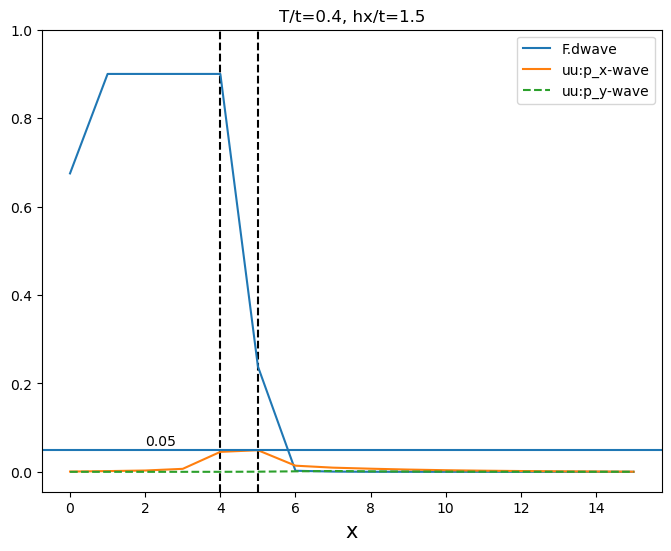

In [24]:
x = np.arange(0, widthD + widthF + widthP)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hx/t={h0}")
axs.axvline(widthD-1, color='black', linestyle='--')
axs.axvline(widthD+widthF-1, color='black', linestyle='--')
# axs.plot(x, np.abs(H.F0), label="onsite")
axs.plot(x, np.abs(F.dwave), label="F.dwave")
# axs.plot(x, np.abs(F.swave), label="F.swave")
# axs.plot(x, np.abs(F.px), label="ud:p_x-wave")
# axs.plot(x, np.abs(F.py), "--", label="ud:p_y-wave")
axs.plot(x, np.abs(Fuu.px), label="uu:p_x-wave")
axs.plot(x, np.abs(Fuu.py), "--", label="uu:p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_ylim(None, 1)
axs.axhline(np.max(np.abs(Fuu.px)))
axs.text(2, np.max(np.abs(Fuu.px))+0.01, f"{np.max(np.abs(Fuu.px)):.2f}")
axs.legend()
plt.show()

In [25]:
print(Fuu.px[10])
print(Fuu.py[10])


(0.003644434497853274-4.734779716785651e-10j)
(1.6807395552138407e-06+0.0004569772571398965j)


In [26]:
temps = np.concatenate([
    np.arange(0.001, 0.009 + 1e-12, 0.001),
    np.arange(0.01, 0.25 + 1e-12, 0.01),
    np.arange(0.26, 0.6 + 1e-12, 0.002 )
])  # 164 temps total
print(len(temps))

205
